# Generation of the library

## Read simulation dataset

In [1]:
import xarray as xr

info_ds = xr.open_dataset(
    "inputs/GreenSurge_Cadiz_info.nc",
    decode_times=False,
)
info_ds

<xarray.Dataset> Size: 76kB
Dimensions:                            (element_computation_index: 2801,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 26,
                                        element_forcing_index: 34,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 1503)
Coordinates:
  * element_computation_index          (element_computation_index) int32 11kB ...
  * node_forcing_index                 (node_forcing_index) int32 104B 0 ... 25
  * element_forcing_index              (element_forcing_index) int32 136B 0 ....
  * wind_direction_index               (wind_direction_index) int32 96B 0 ... 23
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 6kB 0 ....
    node_computation_longitude         (node_cumputation_index) float64 12kB ...
    node_computation_latitude          (node_cumputation_index) float64 12kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 34kB ...
    node_forcing_longitude             (node_forcing_index) float64 208B ...
    node_forcing_latitude              (node_forcing_index) float64 208B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 408B ...
    wind_directions                    (wind_direction_index) int32 96B ...
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B ...
    location_name                      object 8B ...
    eddy_viscosity                     int32 4B ...
    chezy_coefficient                  int32 4B ...
    reference_date                     object 8B ...
    forcing_time_step                  int32 4B ...
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-03-05 14:22:11

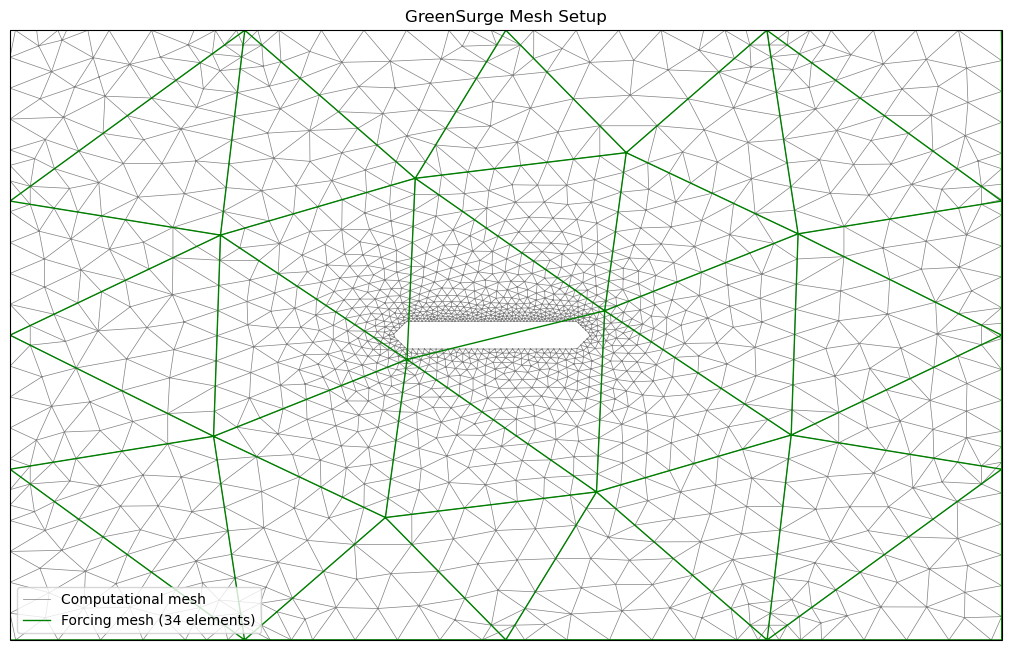

In [2]:
from bluemath_tk.additive.additive import plot_additive_setup

fig, ax = plot_additive_setup(info_ds=info_ds, figsize=(10, 10))

## Wrapper input data

In [3]:
from datetime import datetime, timedelta

import numpy as np

wind_direction_indices = info_ds.wind_direction_index.values
element_indices = info_ds.element_forcing_index.values
num_directions = len(wind_direction_indices)
num_elements = len(element_indices)

direction_grid, element_grid = np.meshgrid(wind_direction_indices, element_indices)
flattened_directions = direction_grid.flatten()
flattened_elements = element_grid.flatten()

reference_datetime = datetime.strptime(
    str(info_ds.reference_date.values), "%Y-%m-%d %H:%M:%S"
)
simulation_end_datetime = reference_datetime + timedelta(
    hours=int(info_ds.simulation_duration_hours.values)
)

# Parameters for the metamodel (per element and direction)
metamodel_parameters = {
    "direction": flattened_directions,
    "tesela": flattened_elements,
}

# Fixed simulation parameters
fixed_parameters = {
    "MapInterval": 3600 * info_ds.time_step_hours.values,
    "StartDateTime": reference_datetime.strftime("%Y%m%d.%H%M%S"),
    "StopDateTime": simulation_end_datetime.strftime("%Y%m%d.%H%M%S"),
    "dt_forz": 3600 * info_ds.forcing_time_step.values,
    "ds_GFD_info": info_ds,
    "wind_magnitude": info_ds.wind_speed.values,
    "simul_time": info_ds.simulation_duration_hours.values,
    "dir_steps": num_directions,
    "time_step_comp": 3600 * info_ds.forcing_time_step.values,
    "forcing_file": "wind_forcing.wind"
}


## Wraper construction

In [4]:
from bluemath_tk.wrappers.swan.swan_wrapper import GreenWavesWrapper

swan_wrapper = GreenWavesWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir="outputs/GreenSurge_Cadiz",
)

2026-03-05 17:31:50,876 - GreenWavesWrapper - WARNING - Parameter direction is not in the default_parameters
2026-03-05 17:31:50,876 - GreenWavesWrapper - WARNING - Parameter tesela is not in the default_parameters


## Case generation

In [5]:
swan_wrapper.build_cases(
    cases_name_format=lambda ctx: f"GF_T_{ctx.get('tesela')}_D_{ctx.get('direction')}",
)